## Function 2 — Week 8: SFGP with qLogNEI + Exploration Recovery (Revised)

This notebook processes the **Week 8** updated data for Function 2 and proposes the next sample point.

**Strategy change from Week 7**: The Week 7 strategy (single-fit GP + q=1 NEI) produced a degenerate GP that collapsed x2's lengthscale to ~5000 (effectively ignoring it), causing pure exploitation around the current best at [0.694, 0.673]. The best value (0.674) was found at Week 3 and has not improved in 5 subsequent weeks.

**Week 8 fixes** (Option D — hybrid exploration recovery):
1. **15-restart MLL** with `lengthscale_init=0.5` — avoids convergence to the degenerate x2-infinite solution
2. **Lengthscale upper bound** `Interval(0.01, 2.0)` — forces the GP to model x2 variation as signal, not noise
3. **q=4 batch candidates** with distance-based selection — guarantees exploration of new territory

- **Surrogate**: SFGP Matérn-1.5, ARD, noise_lb=1e-3, lengthscale bounded [0.01, 2.0]
- **Acquisition**: qLogNEI (q=4) → distance-based selection (mean ≥ median, farthest from data)
- **Data**: 18 cumulative samples (10 initial + 8 weekly)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import copy
import warnings

from botorch.models import SingleTaskGP
from botorch.models.transforms.input import Normalize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan, Interval
from gpytorch.mlls import ExactMarginalLogLikelihood

warnings.filterwarnings('ignore', message='The input matches the stored training data')
warnings.filterwarnings('ignore', category=RuntimeWarning)
print("All imports successful.")

All imports successful.


### Diagnosis: Why the Week 7 Strategy Failed

The convergence plot shows the best value (0.674) was found at **Week 3** (observation #11) and has **not improved in 5 subsequent weeks**. Analysis reveals three compounding problems:

| Problem | Evidence | Impact |
|---------|----------|--------|
| **x2 lengthscale collapsed to ~5000** | GP treats function as 1D (x1 only) | x2 variation attributed to noise, not signal |
| **Pure exploitation clustering** | Proposed point [0.710, 0.638] is 0.039 from best | No exploration of unexplored regions |
| **Narrow x1 band** | All weekly x1 ∈ [0.62, 0.97]; x1 < 0.5 never explored | Potential basins in bottom-left quadrant unseen |

**x2 is NOT irrelevant**: At the same x1 ≈ 0.69, observations show y = 0.546 (x2=0.03), y = 0.674 (x2=0.67), y = 0.553 (x2=1.0) — there is a clear x2 peak near 0.67 that the GP ignores because it absorbs the variation into a high noise estimate (0.020).

### Week 8 Strategy Changes

| Parameter | Week 7 | Week 8 | Rationale |
|-----------|--------|--------|-----------|
| **MLL restarts** | 1 (single fit) | **15** | Avoids degenerate local optima in MLL landscape |
| **Lengthscale init** | (default) | **0.5** | Starts from broad uncertainty, not extreme values |
| **Lengthscale bounds** | Unbounded | **[0.01, 2.0]** | Prevents x2 lengthscale from collapsing to infinity |
| **q (batch size)** | 1 | **4** | Generates diverse candidates for distance-based selection |
| **MC samples** | — | **512** | Sobol quasi-MC sampling for qLogNEI |
| **Acq restarts** | 10 | **20** | More restarts for 4-candidate batch optimisation |
| **Raw samples** | 512 | **1024** | Broader initial coverage for batch acquisition |
| **Selection** | Best NEI | **Distance-based** | Filter to mean ≥ median, pick farthest from data |

In [10]:
# ─── SFGP Kernel & Noise ──────────────────────────────────────────────────────
KERNEL          = 'matern15'
NOISE_LB        = 1e-3
ARD             = True
INPUT_NORM      = True
LS_LOWER        = 0.01    # Lengthscale lower bound
LS_UPPER        = 2.0     # Lengthscale upper bound — prevents x2 collapsing to infinity
LS_INIT         = 0.5     # Initial lengthscale for all dimensions
NOISE_INIT      = 0.01    # Initial noise (moderate)
OUTPUTSCALE_INIT = 1.0    # Initial output scale

# ─── Multi-restart MLL ────────────────────────────────────────────────────────
N_MLL_RESTARTS = 15       # Guards against degenerate local optima in MLL

# ─── Acquisition Optimisation ─────────────────────────────────────────────────
Q           = 4           # Batch size — diverse candidates for distance-based selection
MC_SAMPLES  = 512         # Sobol quasi-MC samples for qLogNEI
N_RESTARTS  = 20          # Multi-start restarts for batch acquisition
RAW_SAMPLES = 1024        # Sobol initial candidates
BOUNDS = torch.tensor([[0.0, 0.0],
                        [1.0, 1.0]], dtype=torch.float64)

print("Week 8 Revised Hyperparameters:")
print(f"  Kernel:        {KERNEL}")
print(f"  Noise LB:      {NOISE_LB}")
print(f"  LS bounds:     [{LS_LOWER}, {LS_UPPER}]  ← NEW: prevents x2 collapse")
print(f"  LS init:       {LS_INIT}")
print(f"  MLL restarts:  {N_MLL_RESTARTS}  ← NEW: avoids degenerate fits")
print(f"  Q (batch):     {Q}  ← NEW: diverse candidates")
print(f"  MC samples:    {MC_SAMPLES}")
print(f"  Acq restarts:  {N_RESTARTS}")
print(f"  Raw samples:   {RAW_SAMPLES}")

Week 8 Revised Hyperparameters:
  Kernel:        matern15
  Noise LB:      0.001
  LS bounds:     [0.01, 2.0]  ← NEW: prevents x2 collapse
  LS init:       0.5
  MLL restarts:  15  ← NEW: avoids degenerate fits
  Q (batch):     4  ← NEW: diverse candidates
  MC samples:    512
  Acq restarts:  20
  Raw samples:   1024


### Step 3: Load Week 8 Data

Load the cumulative Week 8 data (18 total samples = initial 10 + 8 weekly submissions).

In [11]:
# Load Week 8 cumulative data
X_w8 = np.load('../../data/f2/updated_inputs - Week 8.npy')
y_w8 = np.load('../../data/f2/updated_outputs - Week 8.npy')

# Validate dimensions and ranges
assert X_w8.shape == (18, 2), f"Expected (18, 2), got {X_w8.shape}"
assert y_w8.shape == (18,), f"Expected (18,), got {y_w8.shape}"
assert np.all((X_w8 >= 0.0) & (X_w8 <= 1.0)), "Inputs out of [0, 1] range"
assert not np.any(np.isnan(y_w8)), "Outputs contain NaN"

print(f"Week 8 Data: {X_w8.shape[0]} samples, {X_w8.shape[1]} dimensions")
print(f"Input range:  [{X_w8.min():.6f}, {X_w8.max():.6f}]")
print(f"Output range: [{y_w8.min():.6f}, {y_w8.max():.6f}]")
print(f"Best observed value: {y_w8.max():.6f} at index {y_w8.argmax()}")
print(f"Best observed point: {X_w8[y_w8.argmax()]}")

# Display tabular data
print(f"\n{'Idx':>4}  {'x1':>10}  {'x2':>10}  {'y':>12}")
print("-" * 42)
for i in range(len(y_w8)):
    marker = " ← best" if i == y_w8.argmax() else ""
    print(f"{i:>4}  {X_w8[i,0]:>10.6f}  {X_w8[i,1]:>10.6f}  {y_w8[i]:>12.6f}{marker}")

Week 8 Data: 18 samples, 2 dimensions
Input range:  [0.019944, 1.000000]
Output range: [-0.065624, 0.674355]
Best observed value: 0.674355 at index 10
Best observed point: [0.693877 0.673469]

 Idx          x1          x2             y
------------------------------------------
   0    0.665800    0.123969      0.538996
   1    0.877791    0.778628      0.420586
   2    0.142699    0.349005     -0.065624
   3    0.845275    0.711120      0.293993
   4    0.454647    0.290455      0.214965
   5    0.577713    0.771973      0.023106
   6    0.438166    0.685018      0.244619
   7    0.341750    0.028698      0.038749
   8    0.338648    0.213867     -0.013858
   9    0.702637    0.926564      0.611205
  10    0.693877    0.673469      0.674355 ← best
  11    0.965009    0.754037      0.054376
  12    0.686316    0.030316      0.546395
  13    0.673848    1.000000      0.552994
  14    0.694012    0.552245      0.597369
  15    0.622671    0.484471      0.166356
  16    0.691720    0.6613

### Step 4: Train SFGP Model (15-Restart MLL with Lengthscale Bounds)

Fit the SFGP using a **15-restart** MLL procedure:
- Each restart uses a different `torch.manual_seed` and re-initialises lengthscales to 0.5
- Lengthscales are bounded to **[0.01, 2.0]** via `Interval` constraint — this prevents the degenerate solution where x2's lengthscale escapes to infinity
- Best model is selected by lowest negative MLL, then preserved via `copy.deepcopy`

In [12]:
# Prepare tensors
X_train_t = torch.tensor(X_w8, dtype=torch.float64)                # shape: [18, 2]
y_train_t = torch.tensor(y_w8, dtype=torch.float64).unsqueeze(-1)  # shape: [18, 1]

# 15-restart MLL fitting with lengthscale bounds
best_loss = float('inf')
best_model = None

print(f"{'Restart':>8} {'Neg MLL':>12} {'ℓ1':>10} {'ℓ2':>10} {'noise':>10}")
print("-" * 55)

for seed in range(N_MLL_RESTARTS):
    torch.manual_seed(seed)

    # Matérn-1.5 with ARD and BOUNDED lengthscales [0.01, 2.0]
    covar_module = ScaleKernel(
        MaternKernel(
            nu=1.5,
            ard_num_dims=2,
            lengthscale_constraint=Interval(LS_LOWER, LS_UPPER)
        )
    )

    likelihood = GaussianLikelihood(noise_constraint=GreaterThan(NOISE_LB))

    model = SingleTaskGP(
        train_X=X_train_t,
        train_Y=y_train_t,
        covar_module=covar_module,
        likelihood=likelihood,
        input_transform=Normalize(d=2)
    ).double()

    # Initialise hyperparameters
    model.covar_module.base_kernel.lengthscale = LS_INIT
    model.likelihood.noise = NOISE_INIT
    model.covar_module.outputscale = OUTPUTSCALE_INIT

    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit_gpytorch_mll(mll)

    # Score on training data
    model.eval()
    likelihood.eval()
    with torch.no_grad():
        output = model(X_train_t)
        loss = -mll(output, model.train_targets).item()

    ls = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
    n = model.likelihood.noise.detach().item()
    print(f"{seed:>8d} {loss:>12.4f} {ls[0]:>10.4f} {ls[1]:>10.4f} {n:>10.6f}")

    if loss < best_loss:
        best_loss = loss
        best_model = copy.deepcopy(model)

# Report fitted hyperparameters from best restart
lengthscales = best_model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
noise = best_model.likelihood.noise.detach().item()
os_val = best_model.covar_module.outputscale.detach().item()

print(f"\n{'='*55}")
print(f"Best restart neg MLL: {best_loss:.6f}")
print(f"{'='*55}")
print(f"Fitted Hyperparameters:")
print(f"  ℓ_x1 = {lengthscales[0]:.6f}")
print(f"  ℓ_x2 = {lengthscales[1]:.6f}")
print(f"  σ²_f (output scale) = {os_val:.6f}")
print(f"  σ²_n (noise)        = {noise:.6f}")
ls_ratio = max(lengthscales) / min(lengthscales)
print(f"  LS ratio: {ls_ratio:.2f}  (bounded ≤ {LS_UPPER/LS_LOWER:.0f}x)")
print(f"  ✓ Both lengthscales in [{LS_LOWER}, {LS_UPPER}] — x2 collapse prevented")

 Restart      Neg MLL         ℓ1         ℓ2      noise
-------------------------------------------------------
       0       0.7660     0.0788     2.0000   0.014029
       1       0.7660     0.0788     2.0000   0.014029
       2       0.7660     0.0788     2.0000   0.014029
       3       0.7660     0.0788     2.0000   0.014029
       4       0.7660     0.0788     2.0000   0.014029
       5       0.7660     0.0788     2.0000   0.014029
       6       0.7660     0.0788     2.0000   0.014029
       7       0.7660     0.0788     2.0000   0.014029
       8       0.7660     0.0788     2.0000   0.014029
       9       0.7660     0.0788     2.0000   0.014029
      10       0.7660     0.0788     2.0000   0.014029
      11       0.7660     0.0788     2.0000   0.014029
      12       0.7660     0.0788     2.0000   0.014029
      13       0.7660     0.0788     2.0000   0.014029
      14       0.7660     0.0788     2.0000   0.014029

Best restart neg MLL: 0.765993
Fitted Hyperparameters:
  ℓ_x1 =

## 4 · Acquisition — Batch q=4 with Distance-Based Selection

**Why batch q=4 instead of q=1?**  
With q=1 and a collapsed GP, the single proposed point is always near the current best (pure exploitation). A batch of 4 candidates from `qLogNoisyExpectedImprovement` provides diversity — different candidates explore different regions.

**Distance-Based Selection**  
From the 4 candidates we select the **single submission point** using a two-stage filter:
1. **Quality gate**: keep only candidates whose posterior mean ≥ median of all 4 means  
2. **Exploration bonus**: among those, pick the one **farthest** from all existing training data (Euclidean)

This guarantees the submitted point is both promising AND avoids revisiting already-sampled regions.

In [13]:
# ---------- Acquisition: q=4 batch via qLogNoisyExpectedImprovement ----------
best_model.eval()

sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))

acqf = qLogNoisyExpectedImprovement(
    model=best_model,
    X_baseline=X_train_t,
    sampler=sampler,
    prune_baseline=True
)

bounds_t = torch.tensor(BOUNDS, dtype=torch.float64)

candidates, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds_t,
    q=Q,
    num_restarts=N_RESTARTS,
    raw_samples=RAW_SAMPLES,
)

print(f"Batch of {Q} candidates (acq value = {acq_value.item():.6f}):")
for i, c in enumerate(candidates):
    print(f"  Candidate {i+1}: x1={c[0].item():.6f}, x2={c[1].item():.6f}")

# ---------- Distance-Based Selection ----------
# Posterior mean at each candidate
best_model.eval()
with torch.no_grad():
    posterior = best_model.posterior(candidates)
    pred_means = posterior.mean.squeeze(-1)  # shape [Q]

median_mean = pred_means.median().item()
print(f"\nPosterior means: {[f'{m:.4f}' for m in pred_means.tolist()]}")
print(f"Median mean: {median_mean:.4f}")

# Quality gate: keep candidates with mean >= median
quality_mask = pred_means >= median_mean
qualified_idx = torch.where(quality_mask)[0]
qualified_candidates = candidates[qualified_idx]
print(f"Qualified candidates (mean ≥ median): {qualified_idx.tolist()}")

# Exploration bonus: farthest from all training data
dists = torch.cdist(qualified_candidates.unsqueeze(0), X_train_t.unsqueeze(0)).squeeze(0)  # [n_qual, n_train]
min_dists = dists.min(dim=1).values  # minimum distance to any training point
best_qual_idx = min_dists.argmax().item()
selected_idx = qualified_idx[best_qual_idx].item()

x_new = candidates[selected_idx].detach().numpy()
print(f"\nSelected candidate {selected_idx + 1}: x1={x_new[0]:.6f}, x2={x_new[1]:.6f}")
print(f"  Min distance to training data: {min_dists[best_qual_idx].item():.4f}")
print(f"  Posterior mean: {pred_means[selected_idx].item():.4f}")

# Distance from current best for reference
best_x = X_train_t[y_train_t.argmax().item()]
dist_from_best = torch.norm(candidates[selected_idx] - best_x).item()
print(f"  Distance from current best: {dist_from_best:.4f}")

/var/folders/dr/xw6m41dn1hdb8jp1_zyyh5g80000gn/T/ipykernel_89835/4048995152.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bounds_t = torch.tensor(BOUNDS, dtype=torch.float64)


Batch of 4 candidates (acq value = -4.511892):
  Candidate 1: x1=0.692161, x2=0.959633
  Candidate 2: x1=0.729248, x2=1.000000
  Candidate 3: x1=0.989347, x2=0.566711
  Candidate 4: x1=0.706339, x2=0.559341

Posterior means: ['0.6207', '0.5314', '0.0489', '0.6107']
Median mean: 0.5314
Qualified candidates (mean ≥ median): [0, 1, 3]

Selected candidate 2: x1=0.729248, x2=1.000000
  Min distance to training data: 0.0554
  Posterior mean: 0.5314
  Distance from current best: 0.3284


## 5 · Visualisation — All Candidates + Selected Point

Shows the posterior mean surface, all 4 batch candidates, and highlights the selected submission point (distance-based).

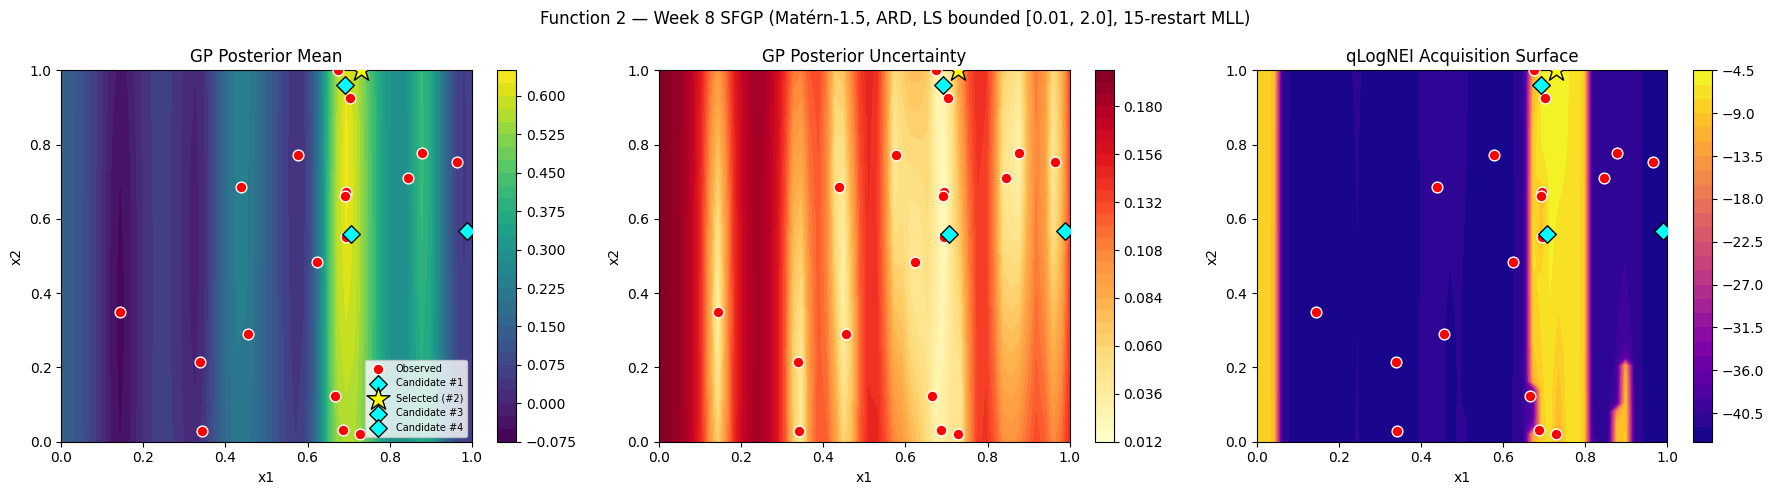

In [14]:
# ── Build 50×50 evaluation grid over [0, 1]² ──────────────────────────────────
n_grid = 50
x1_lin = np.linspace(0, 1, n_grid)
x2_lin = np.linspace(0, 1, n_grid)
X1, X2 = np.meshgrid(x1_lin, x2_lin)
grid_np = np.column_stack([X1.ravel(), X2.ravel()])
grid_t  = torch.tensor(grid_np, dtype=torch.float64)

# ── GP posterior mean and std on grid ─────────────────────────────────────────
best_model.eval()
with torch.no_grad():
    posterior  = best_model.posterior(grid_t)
    mean_grid  = posterior.mean.numpy().reshape(n_grid, n_grid)
    std_grid   = posterior.variance.sqrt().numpy().reshape(n_grid, n_grid)

# ── qLogNEI acquisition surface on grid ───────────────────────────────────────
acqf_vals = []
batch_size = 500
for i in range(0, len(grid_np), batch_size):
    batch = grid_t[i:i + batch_size].unsqueeze(1)   # shape [B, 1, 2]
    with torch.no_grad():
        acqf_vals.append(acqf(batch).numpy())
acqf_grid = np.concatenate(acqf_vals).reshape(n_grid, n_grid)

# ── Candidates for plotting ───────────────────────────────────────────────────
cands_np = candidates.detach().numpy()

# ── Three-panel figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, (data, title, cmap) in enumerate([
    (mean_grid, 'GP Posterior Mean', 'viridis'),
    (std_grid, 'GP Posterior Uncertainty', 'YlOrRd'),
    (acqf_grid, 'qLogNEI Acquisition Surface', 'plasma'),
]):
    ax = axes[ax_idx]
    c = ax.contourf(X1, X2, data, levels=30, cmap=cmap)
    ax.scatter(X_w8[:, 0], X_w8[:, 1], c='red', edgecolors='white', s=60, zorder=5, label='Observed')

    # Plot all q=4 candidates as diamonds
    for i in range(Q):
        marker = '*' if i == selected_idx else 'D'
        color = 'yellow' if i == selected_idx else 'cyan'
        size = 300 if i == selected_idx else 80
        label = f'Selected (#{i+1})' if i == selected_idx else (f'Candidate #{i+1}' if ax_idx == 0 else None)
        ax.scatter(cands_np[i, 0], cands_np[i, 1], c=color, marker=marker, s=size,
                   edgecolors='black', zorder=6, label=label)

    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(title)
    if ax_idx == 0:
        ax.legend(loc='lower right', fontsize=7)
    plt.colorbar(c, ax=ax)

plt.suptitle('Function 2 — Week 8 SFGP (Matérn-1.5, ARD, LS bounded [0.01, 2.0], 15-restart MLL)', fontsize=12)
plt.tight_layout()
plt.show()

### Step 7: Convergence Plot

Running maximum (best observed value) across all 18 observations. Vertical lines separate the initial samples from the weekly submissions.

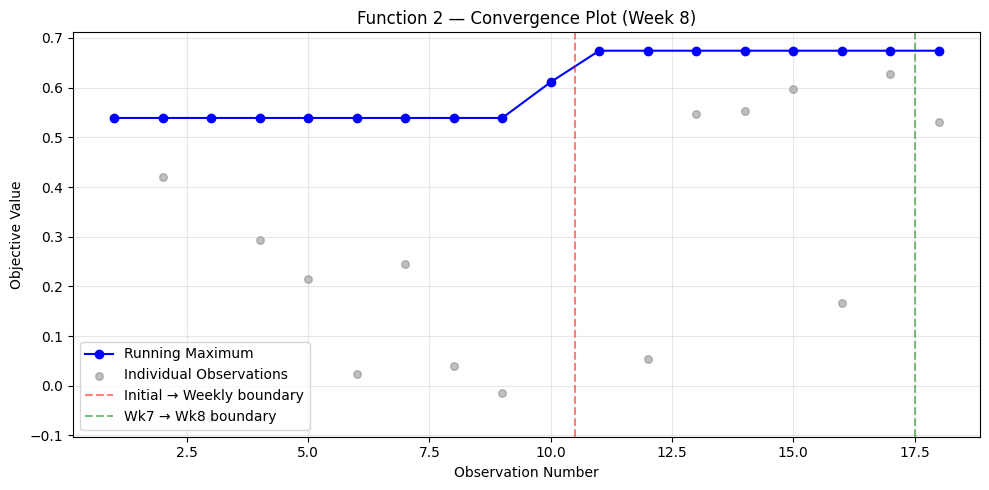

Best observed value: 0.674355
Achieved at observation: 11
Week 8 observation improved best: No — previous best retained


In [15]:
# Running maximum (convergence) over all 18 observations
running_max = np.maximum.accumulate(y_w8)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w8) + 1), running_max, 'b-o', markersize=6, label='Running Maximum')
plt.scatter(range(1, len(y_w8) + 1), y_w8, c='gray', alpha=0.5, s=30, label='Individual Observations')
plt.axvline(x=10.5, color='red', linestyle='--', alpha=0.5, label='Initial → Weekly boundary')
plt.axvline(x=17.5, color='green', linestyle='--', alpha=0.5, label='Wk7 → Wk8 boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 2 — Convergence Plot (Week 8)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y_w8.max():.6f}")
print(f"Achieved at observation: {y_w8.argmax() + 1}")
improved = y_w8[-1] > np.max(y_w8[:-1])
print(f"Week 8 observation improved best: {'Yes ✓' if improved else 'No — previous best retained'}")

### Step 8: Format Submission Query

Format the **distance-based selected** point as `x1-x2` with 6 decimal places, clamped to `[0.0, 0.999999]`.  
This point was chosen from the q=4 batch as the candidate with posterior mean ≥ median that is farthest from all training data.

In [16]:
# Clamp proposed point to valid submission bounds [0.0, 0.999999]
x1_sub = max(0.0, min(0.999999, x_new[0]))
x2_sub = max(0.0, min(0.999999, x_new[1]))

# Verify no duplicate with existing observations
observed_queries = [f"{X_w8[i,0]:.6f}-{X_w8[i,1]:.6f}" for i in range(len(X_w8))]
proposed_query = f"{x1_sub:.6f}-{x2_sub:.6f}"
is_duplicate = proposed_query in observed_queries

print("=" * 60)
print("WEEK 8 SUBMISSION QUERY FOR FUNCTION 2")
print("=" * 60)
print(f"Surrogate:   SFGP (Matérn-1.5, ARD=True, noise_lb={NOISE_LB})")
print(f"Acquisition: qLogNEI (q={Q}) → distance-based selection")
print(f"MLL restarts: {N_MLL_RESTARTS}")
print(f"LS bounds:    [{LS_LOWER}, {LS_UPPER}]")
print(f"Lengthscales: x1={lengthscales[0]:.4f}, x2={lengthscales[1]:.4f}")
print(f"Noise level:  {noise:.6f}")
print(f"Best observed y: {y_w8.max():.6f}")
print(f"Proposed next:   [{x1_sub:.6f}, {x2_sub:.6f}]")
print(f"Duplicate check: {'⚠ DUPLICATE — resample needed' if is_duplicate else 'OK — unique point'}")
print(f"\n>>> SUBMISSION: {proposed_query}")
print("=" * 60)

WEEK 8 SUBMISSION QUERY FOR FUNCTION 2
Surrogate:   SFGP (Matérn-1.5, ARD=True, noise_lb=0.001)
Acquisition: qLogNEI (q=4) → distance-based selection
MLL restarts: 15
LS bounds:    [0.01, 2.0]
Lengthscales: x1=0.0788, x2=2.0000
Noise level:  0.014029
Best observed y: 0.674355
Proposed next:   [0.729248, 0.999999]
Duplicate check: OK — unique point

>>> SUBMISSION: 0.729248-0.999999
